In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [2]:
Spotify_limpio = pd.read_csv('Spotify_data_total.csv')

In [3]:
Spotify_limpio.head()

,EDAD,GENERO,ANTIGUEDAD,DISPOSITIVO,SUSCRIPCION,QUIERE_PREMIUM,PREMIUM_PREFERIDO,CONTENIDO_PREFERIDO,GENERO_FAV_MUSICA,FRANJA_HORARIA,...,MOMENTO_MUSICA,DESCUBRIMIENTO,VALORACION_RECOMENDACIONES,FRECUENCIA_POD,GENERO_FAV_POD,FORMATO_PREFERIDO_POD,PREFERENCIA_PRESENTADOR_POD,PREFERENCIA_DURACION_POD,SATISFACCION_POD,CANTIDAD_DISPOSITIVOS
0,20-35,Mujer,Más de 2 años,Altavoz Inteligente,Free,Si,Family Plan-Rs 179/month,Podcast,Melody,Noche,...,Tiempo libre,Listas de reproducción,3,Diariamente,Comedia,Entrevista,Ambos,Ambos,Ok,1
1,12-20,Hombre,Más de 2 años,Ordenador,Free,Si,Individual Plan- Rs 119/ month,Podcast,Rap,Tarde,...,Entrenamiento,Listas de reproducción,2,Varias veces por semana,Comedia,Entrevista,Ambos,No aplicable/Ninguno,Satisfecho,1
2,35-60,Otro,De 6 meses a 1 año,Altavoz Inteligente,Free,Si,Student Plan-Rs 59/month,Podcast,Pop,Noche,...,"Horas de estudio, Mientras viaja",Listas de reproducción,4,Una vez por semana,Deportes,Entrevista,No aplicable/Ninguno,Ambos,Satisfecho,1
3,20-35,Mujer,De 1 año a 2 años,"Smartphone, Altavoz Inteligente",Free,No,No aplicable/Ninguno,Music,Melody,Noche,...,"Horario de oficina, Entrenamiento, Tiempo libre","Recomendaciones, Listas de reproducción",4,Nunca,No aplicable/Ninguno,No aplicable/Ninguno,No aplicable/Ninguno,No aplicable/Ninguno,Ok,2
4,20-35,Mujer,De 1 año a 2 años,Smartphone,Free,No,No aplicable/Ninguno,Music,Melody,Noche,...,Tiempo libre,"Recomendaciones, Listas de reproducción",4,Raramente,Estilo de vida y salud,Relato,Famoso,Ambos,Ok,1


In [4]:
Spotify_limpio.columns

Index(['EDAD', 'GENERO', 'ANTIGUEDAD', 'DISPOSITIVO', 'SUSCRIPCION',
       'QUIERE_PREMIUM', 'PREMIUM_PREFERIDO', 'CONTENIDO_PREFERIDO',
       'GENERO_FAV_MUSICA', 'FRANJA_HORARIA', 'ESTADO_ANIMO', 'MOMENTO_MUSICA',
       'DESCUBRIMIENTO', 'VALORACION_RECOMENDACIONES', 'FRECUENCIA_POD',
       'GENERO_FAV_POD', 'FORMATO_PREFERIDO_POD',
       'PREFERENCIA_PRESENTADOR_POD', 'PREFERENCIA_DURACION_POD',
       'SATISFACCION_POD', 'CANTIDAD_DISPOSITIVOS'],
      dtype='object')

In [5]:
Spotify_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   EDAD                         520 non-null    object
 1   GENERO                       520 non-null    object
 2   ANTIGUEDAD                   520 non-null    object
 3   DISPOSITIVO                  520 non-null    object
 4   SUSCRIPCION                  520 non-null    object
 5   QUIERE_PREMIUM               520 non-null    object
 6   PREMIUM_PREFERIDO            520 non-null    object
 7   CONTENIDO_PREFERIDO          520 non-null    object
 8   GENERO_FAV_MUSICA            520 non-null    object
 9   FRANJA_HORARIA               520 non-null    object
 10  ESTADO_ANIMO                 520 non-null    object
 11  MOMENTO_MUSICA               520 non-null    object
 12  DESCUBRIMIENTO               520 non-null    object
 13  VALORACION_RECOMENDACIONES   520 no

### Codificación de columnas multirrespuesta

In [6]:
multirrespuesta_cols = ["DISPOSITIVO", "MOMENTO_MUSICA", "DESCUBRIMIENTO", "ESTADO_ANIMO", "GENERO_FAV_POD"]

for col in multirrespuesta_cols:
    Spotify_limpio[col] = Spotify_limpio[col].str.split(r",\s*")

for col in multirrespuesta_cols:
    dummies = Spotify_limpio[col].str.join("|").str.get_dummies()
    dummies = dummies.add_prefix(col + "_")
    Spotify_limpio = pd.concat([Spotify_limpio, dummies], axis=1)
    Spotify_limpio.drop(columns=[col], inplace=True)

In [7]:
Spotify_limpio

,EDAD,GENERO,ANTIGUEDAD,SUSCRIPCION,QUIERE_PREMIUM,PREMIUM_PREFERIDO,CONTENIDO_PREFERIDO,GENERO_FAV_MUSICA,FRANJA_HORARIA,VALORACION_RECOMENDACIONES,...,GENERO_FAV_POD_Estilo de vida y salud,GENERO_FAV_POD_Finanzas y actualidad,GENERO_FAV_POD_Historias,GENERO_FAV_POD_Misterio y crímenes,GENERO_FAV_POD_Negocios,GENERO_FAV_POD_No aplicable/Ninguno,GENERO_FAV_POD_Novelas,GENERO_FAV_POD_Política e información (temas de interés),GENERO_FAV_POD_Salud y fitness,GENERO_FAV_POD_Tecnología
0,20-35,Mujer,Más de 2 años,Free,Si,Family Plan-Rs 179/month,Podcast,Melody,Noche,3,...,0,0,0,0,0,0,0,0,0,0
1,12-20,Hombre,Más de 2 años,Free,Si,Individual Plan- Rs 119/ month,Podcast,Rap,Tarde,2,...,0,0,0,0,0,0,0,0,0,0
2,35-60,Otro,De 6 meses a 1 año,Free,Si,Student Plan-Rs 59/month,Podcast,Pop,Noche,4,...,0,0,0,0,0,0,0,0,0,0
3,20-35,Mujer,De 1 año a 2 años,Free,No,No aplicable/Ninguno,Music,Melody,Noche,4,...,0,0,0,0,0,1,0,0,0,0
4,20-35,Mujer,De 1 año a 2 años,Free,No,No aplicable/Ninguno,Music,Melody,Noche,4,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,20-35,Mujer,Más de 2 años,Free,Si,Student Plan-Rs 59/month,Music,Pop,Mañana,5,...,1,0,0,0,0,0,0,0,0,0
516,20-35,Mujer,Más de 2 años,Free,Si,Student Plan-Rs 59/month,Music,Pop,Noche,2,...,0,0,0,0,0,0,0,0,0,0
517,20-35,Mujer,Más de 2 años,Free,No,Student Plan-Rs 59/month,Music,Pop,Noche,3,...,0,0,0,0,0,1,0,0,0,0
518,20-35,Mujer,De 6 meses a 1 año,Premium,Si,Individual Plan- Rs 119/ month,Music,Melody,Noche,2,...,0,0,0,0,0,0,0,0,0,0


### Codificación de la tabla completa

In [8]:
Spotify_codificado = pd.get_dummies(Spotify_limpio, drop_first=True)

In [9]:
Spotify_codificado.head()

,VALORACION_RECOMENDACIONES,CANTIDAD_DISPOSITIVOS,DISPOSITIVO_Altavoz Inteligente,DISPOSITIVO_Dispositivo Portatil Inteligente,DISPOSITIVO_Ordenador,DISPOSITIVO_Smartphone,MOMENTO_MUSICA_Aleatorio,MOMENTO_MUSICA_Antes de dormir,MOMENTO_MUSICA_Cocinando,MOMENTO_MUSICA_Entrenamiento,...,PREFERENCIA_PRESENTADOR_POD_Desconocido,PREFERENCIA_PRESENTADOR_POD_Famoso,PREFERENCIA_PRESENTADOR_POD_No aplicable/Ninguno,PREFERENCIA_DURACION_POD_Corto,PREFERENCIA_DURACION_POD_Largo,PREFERENCIA_DURACION_POD_No aplicable/Ninguno,SATISFACCION_POD_Muy insatisfecho,SATISFACCION_POD_Muy satisfecho,SATISFACCION_POD_Ok,SATISFACCION_POD_Satisfecho
0,3,1,1,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,2,1,0,0,1,0,0,0,0,1,...,False,False,False,False,False,True,False,False,False,True
2,4,1,1,0,0,0,0,0,0,0,...,False,False,True,False,False,False,False,False,False,True
3,4,2,1,0,0,1,0,0,0,1,...,False,False,True,False,False,True,False,False,True,False
4,4,1,0,0,0,1,0,0,0,0,...,False,True,False,False,False,False,False,False,True,False


In [10]:
for col in Spotify_limpio.columns:
    print(f"\n--- {col} ---")
    print(Spotify_limpio[col].value_counts())


--- EDAD ---
EDAD
20-35    422
12-20     71
35-60     23
6-12       3
60+        1
Name: count, dtype: int64

--- GENERO ---
GENERO
Mujer     391
Hombre    114
Otro       15
Name: count, dtype: int64

--- ANTIGUEDAD ---
ANTIGUEDAD
Más de 2 años         169
De 1 año a 2 años     141
De 6 meses a 1 año    119
Menos de 6 meses       91
Name: count, dtype: int64

--- SUSCRIPCION ---
SUSCRIPCION
Free       424
Premium     96
Name: count, dtype: int64

--- QUIERE_PREMIUM ---
QUIERE_PREMIUM
No    334
Si    186
Name: count, dtype: int64

--- PREMIUM_PREFERIDO ---
PREMIUM_PREFERIDO
No aplicable/Ninguno              208
Individual Plan- Rs 119/ month     95
Student Plan-Rs 59/month           94
Duo plan- Rs 149/month             84
Family Plan-Rs 179/month           39
Name: count, dtype: int64

--- CONTENIDO_PREFERIDO ---
CONTENIDO_PREFERIDO
Music      410
Podcast    110
Name: count, dtype: int64

--- GENERO_FAV_MUSICA ---
GENERO_FAV_MUSICA
Melody                       259
classical           

### Definir X e Y

Dada la información del usuario (edad, género musical, dispositivos, hábitos, etc.), ¿qué probabilidad hay de que quiera Spotify Premium?

In [11]:
y = Spotify_codificado["QUIERE_PREMIUM_Si"]

import re
cols_excluir = [c for c in Spotify_codificado.columns
                if re.search(r"^(QUIERE_PREMIUM_|SUSCRIPCION_)", c) or c.startswith("PREMIUM_")]

X = Spotify_codificado.drop(columns=cols_excluir, errors="ignore")


### Train y Test división. Entrenamiento del modelo

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

Verificar que X_train, X_test tienen las mismas columnas

In [13]:
print(X_train.shape)
print(X_test.shape)
print((X_train.columns == X_test.columns).all())

(390, 87)
(130, 87)
True


In [14]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000000)
rfe = RFE(lr, n_features_to_select=25)
rfe = rfe.fit(X_train, y_train)

In [15]:
tabla_columnas = pd.DataFrame({
    "columna": X_train.columns, 
    "SeQueda": rfe.support_,
    "Posicion": rfe.ranking_
})
tabla_columnas.sort_values("Posicion")

,columna,SeQueda,Posicion
27,GENERO_FAV_POD_Actualidad,True,1
26,ESTADO_ANIMO_Tristeza,True,1
25,ESTADO_ANIMO_Reuniones Sociales,True,1
22,DESCUBRIMIENTO_Redes sociales,True,1
20,DESCUBRIMIENTO_Radio,True,1
...,...,...,...
31,GENERO_FAV_POD_Contenido informativo,False,59
13,MOMENTO_MUSICA_Por la noche,False,60
57,"GENERO_FAV_MUSICA_Classical & melody, dance",False,61
33,GENERO_FAV_POD_De todo,False,62


### Modelo final

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

cols_seleccionadas = X_train.columns[rfe.support_]

scaler = StandardScaler()

X_train_sel = X_train.loc[:, cols_seleccionadas]
X_test_sel = X_test.loc[:, cols_seleccionadas]

X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

modelo = LogisticRegression(max_iter=10000)
modelo.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [17]:
modelo.n_iter_

array([14], dtype=int32)

### Evaluación

In [18]:
pred = modelo.predict(X_test_scaled)
proba = modelo.predict_proba(X_test_scaled)[:,1]

#### Matriz de confusión manual

TP = predijo Sí y era Sí

TN = predijo No y era No

FP = predijo Sí y era No

FN = predijo No y era Sí

In [19]:
TP = ((y_test == 1) & (pred == 1)).sum()
TN = ((y_test == 0) & (pred == 0)).sum()
FP = ((y_test == 0) & (pred == 1)).sum()
FN = ((y_test == 1) & (pred == 0)).sum()

print("TP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

TP = 23
TN = 67
FP = 16
FN = 24


#### Accuracy

In [20]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
print("Accuracy =", accuracy)

Accuracy = 0.6923076923076923


#### Sensibilidad

De todos los que realmente querían Premium, cuántos detectó bien el modelo.

In [21]:
sensibilidad = TP / (TP + FN)
print("Sensibilidad =", sensibilidad)

Sensibilidad = 0.48936170212765956


#### Especificidad

De todos los que realmente NO querían Premium, cuántos clasificó bien como No.

In [22]:
especificidad = TN / (TN + FP)
print("Especificidad =", especificidad)

Especificidad = 0.8072289156626506


#### Valor predictivo de positivos

In [23]:
vpp = TP / (TP + FP)
print("Valor predictivo positivo (VPP)=", vpp)

Valor predictivo positivo (VPP)= 0.5897435897435898


#### Curva ROC

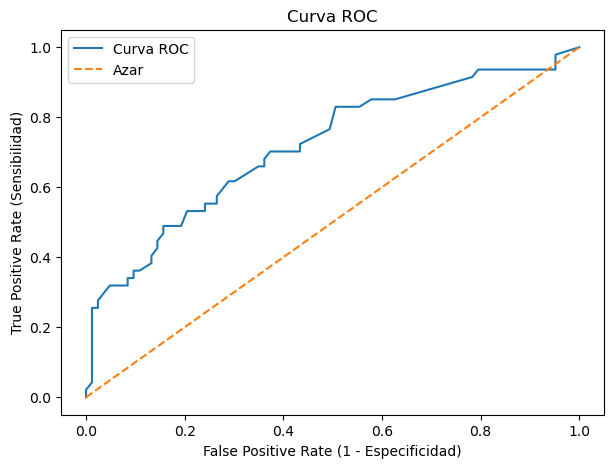

In [24]:
umbrales = np.linspace(0, 1, 101)

tpr_list = []
fpr_list = []

for umbral in umbrales:
    pred_umbral = (proba >= umbral).astype(int)
    
    TP = ((y_test == 1) & (pred_umbral == 1)).sum()
    TN = ((y_test == 0) & (pred_umbral == 0)).sum()
    FP = ((y_test == 0) & (pred_umbral == 1)).sum()
    FN = ((y_test == 1) & (pred_umbral == 0)).sum()
    
    sensibilidad = TP / (TP + FN) if (TP + FN) > 0 else 0
    especificidad = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    tpr = sensibilidad
    fpr = 1 - especificidad
    
    tpr_list.append(tpr)
    fpr_list.append(fpr)

plt.figure(figsize=(7,5))
plt.plot(fpr_list, tpr_list, label="Curva ROC")
plt.plot([0,1], [0,1], linestyle="--", label="Azar")
plt.xlabel("False Positive Rate (1 - Especificidad)")
plt.ylabel("True Positive Rate (Sensibilidad)")
plt.title("Curva ROC")
plt.legend()
plt.show()

In [25]:
área_bajo_curva = abs(np.trapezoid(tpr_list, fpr_list))
print("AUC=", área_bajo_curva)

AUC= 0.7171238144065624


### Calcular umbral óptimo

In [26]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_test, proba)

youden = tpr - fpr
idx_opt = np.argmax(youden)

threshold_opt = thresholds[idx_opt]
tpr_opt = tpr[idx_opt]
fpr_opt = fpr[idx_opt]
spec_opt = 1 - fpr_opt

print("Umbral óptimo:", threshold_opt)
print("Sensibilidad en ese umbral:", tpr_opt)
print("Especificidad en ese umbral:", spec_opt)
print("Índice de Youden:", youden[idx_opt])

Umbral óptimo: 0.543163556183547
Sensibilidad en ese umbral: 0.48936170212765956
Especificidad en ese umbral: 0.8433734939759037
Índice de Youden: 0.33273519610356317


### Clasificación según umbral óptimo

In [27]:
pred_opt = (proba >= threshold_opt).astype(int)

#### Matriz de confusión según umbral óptimo

In [28]:
TP = ((y_test == 1) & (pred_opt == 1)).sum()
TN = ((y_test == 0) & (pred_opt == 0)).sum()
FP = ((y_test == 0) & (pred_opt == 1)).sum()
FN = ((y_test == 1) & (pred_opt == 0)).sum()

print("TP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

accuracy = (TP + TN) / (TP + TN + FP + FN)
sensibilidad = TP / (TP + FN)
especificidad = TN / (TN + FP)
vpp = TP / (TP + FP)


print("Accuracy =", accuracy)
print("Sensibilidad =", sensibilidad)
print("Especificidad =", especificidad)
print("Valor predictivo positivo (VPP)=", vpp)

TP = 23
TN = 70
FP = 13
FN = 24
Accuracy = 0.7153846153846154
Sensibilidad = 0.48936170212765956
Especificidad = 0.8433734939759037
Valor predictivo positivo (VPP)= 0.6388888888888888


Aunque habitualmente se utiliza un umbral de 0.5 para clasificar usuarios, el análisis de la curva ROC permitió identificar un umbral óptimo alternativo mediante el índice de Youden, mejorando el equilibrio entre sensibilidad y especificidad.

In [29]:
coeficientes = pd.Series(modelo.coef_[0], index=cols_seleccionadas)
coeficientes = coeficientes.sort_values()
print(coeficientes)

DISPOSITIVO_Smartphone                   -0.409965
GENERO_FAV_MUSICA_Kpop                   -0.342779
DESCUBRIMIENTO_Redes sociales            -0.328442
SATISFACCION_POD_Muy insatisfecho        -0.328088
FRECUENCIA_POD_Varias veces por semana   -0.262462
ANTIGUEDAD_Menos de 6 meses              -0.228724
ESTADO_ANIMO_Reuniones Sociales          -0.214656
GENERO_FAV_MUSICA_Rock                    0.106479
DESCUBRIMIENTO_Radio                      0.205235
MOMENTO_MUSICA_Horas de estudio           0.212478
GENERO_FAV_POD_Estilo de vida y salud     0.228215
CONTENIDO_PREFERIDO_Podcast               0.230382
DESCUBRIMIENTO_Búsqueda                   0.236542
GENERO_FAV_POD_Tecnología                 0.238214
GENERO_FAV_MUSICA_Rap                     0.250147
GENERO_FAV_POD_Historias                  0.261786
GENERO_FAV_POD_Finanzas y actualidad      0.261786
EDAD_20-35                                0.268307
PREFERENCIA_DURACION_POD_Largo            0.276238
FORMATO_PREFERIDO_POD_Educativo

### Gráfico de las variables que influyen en la intención de pagar Premium

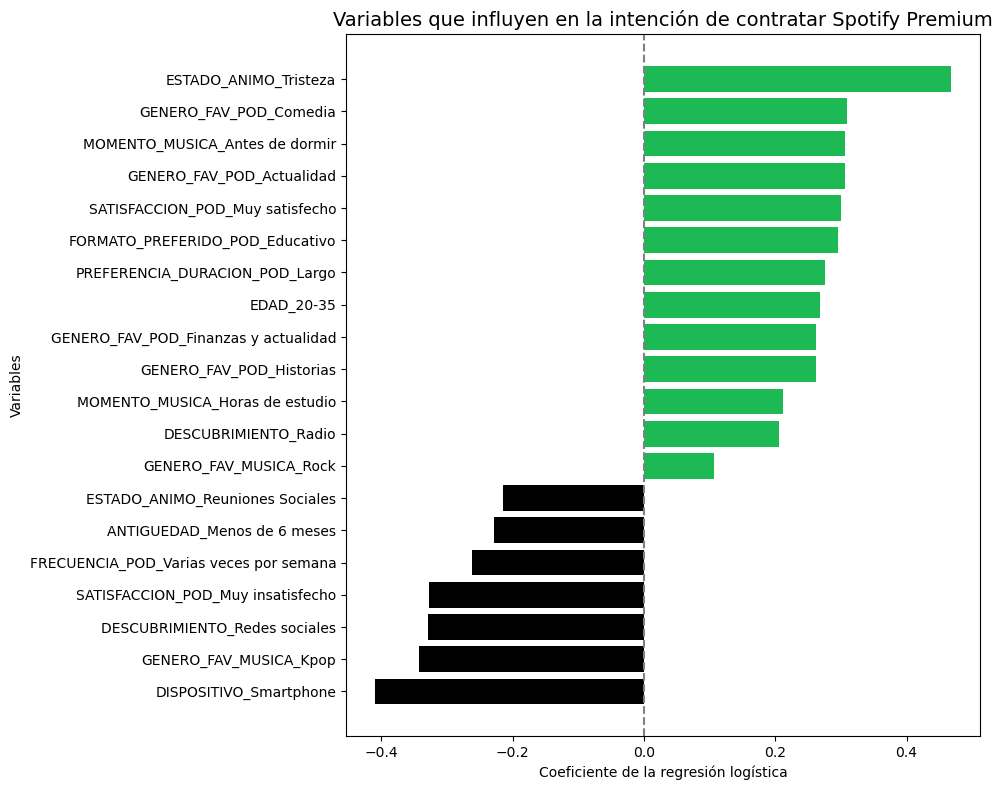

In [30]:
top = pd.concat([coeficientes.head(10), coeficientes.tail(10)])
top = top.sort_values()
colores = ["#1DB954" if v > 0 else "black" for v in top]
plt.figure(figsize=(10,8))
plt.barh(top.index, top.values, color=colores)
plt.axvline(0, color="gray", linestyle="--")
plt.title("Variables que influyen en la intención de contratar Spotify Premium", fontsize=14)
plt.xlabel("Coeficiente de la regresión logística")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

In [31]:
coeficientes.sort_values()

DISPOSITIVO_Smartphone                   -0.409965
GENERO_FAV_MUSICA_Kpop                   -0.342779
DESCUBRIMIENTO_Redes sociales            -0.328442
SATISFACCION_POD_Muy insatisfecho        -0.328088
FRECUENCIA_POD_Varias veces por semana   -0.262462
ANTIGUEDAD_Menos de 6 meses              -0.228724
ESTADO_ANIMO_Reuniones Sociales          -0.214656
GENERO_FAV_MUSICA_Rock                    0.106479
DESCUBRIMIENTO_Radio                      0.205235
MOMENTO_MUSICA_Horas de estudio           0.212478
GENERO_FAV_POD_Estilo de vida y salud     0.228215
CONTENIDO_PREFERIDO_Podcast               0.230382
DESCUBRIMIENTO_Búsqueda                   0.236542
GENERO_FAV_POD_Tecnología                 0.238214
GENERO_FAV_MUSICA_Rap                     0.250147
GENERO_FAV_POD_Historias                  0.261786
GENERO_FAV_POD_Finanzas y actualidad      0.261786
EDAD_20-35                                0.268307
PREFERENCIA_DURACION_POD_Largo            0.276238
FORMATO_PREFERIDO_POD_Educativo

El análisis de los coeficientes de la regresión logística revela que variables relacionadas con el consumo de podcasts, determinados contextos de escucha (como antes de dormir o durante el estudio) y estados emocionales asociados al uso de la música están positivamente relacionadas con la intención de contratar Spotify Premium. Por el contrario, variables asociadas a un consumo más casual o centrado en el uso del smartphone muestran una relación negativa con dicha intención.

'C:\\Users\\Usuario\\Downloads\\SPOTIFY'